In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fixes from Day 2
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop(columns=['customerID'], inplace=True)

In [2]:
# 1. Average monthly spend over entire tenure
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

# 2. Tenure groups — new, mid, long term customer
df['TenureGroup'] = pd.cut(df['tenure'], 
                            bins=[0, 12, 36, 72],
                            labels=['New', 'Mid', 'Long'])

# 3. Number of services subscribed
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 
                'StreamingTV', 'StreamingMovies']

# Count Yes values across service columns
df['NumServices'] = df[service_cols].apply(
    lambda row: (row == 'Yes').sum(), axis=1)

# 4. High value customer flag
df['IsHighValue'] = (df['MonthlyCharges'] > 
                     df['MonthlyCharges'].median()).astype(int)

# 5. Month to month contract flag (high risk)
df['IsMonthToMonth'] = (df['Contract'] == 'Month-to-month').astype(int)

# 6. Charge increase indicator
df['ChargePerService'] = df['MonthlyCharges'] / (df['NumServices'] + 1)

print("New features created!")
print(df[['AvgMonthlySpend', 'TenureGroup', 'NumServices', 
          'IsHighValue', 'IsMonthToMonth', 'ChargePerService']].head(10))

New features created!
   AvgMonthlySpend TenureGroup  NumServices  IsHighValue  IsMonthToMonth  \
0        14.925000         New            1            0               1   
1        53.985714         Mid            3            0               0   
2        36.050000         New            3            0               1   
3        40.016304        Long            3            0               0   
4        50.550000         New            1            1               1   
5        91.166667         New            4            1               1   
6        84.756522         Mid            3            1               1   
7        27.445455         New            1            0               1   
8       105.036207         Mid            5            1               1   
9        55.364286        Long            3            0               0   

   ChargePerService  
0         14.925000  
1         14.237500  
2         13.462500  
3         10.575000  
4         35.350000  
5        

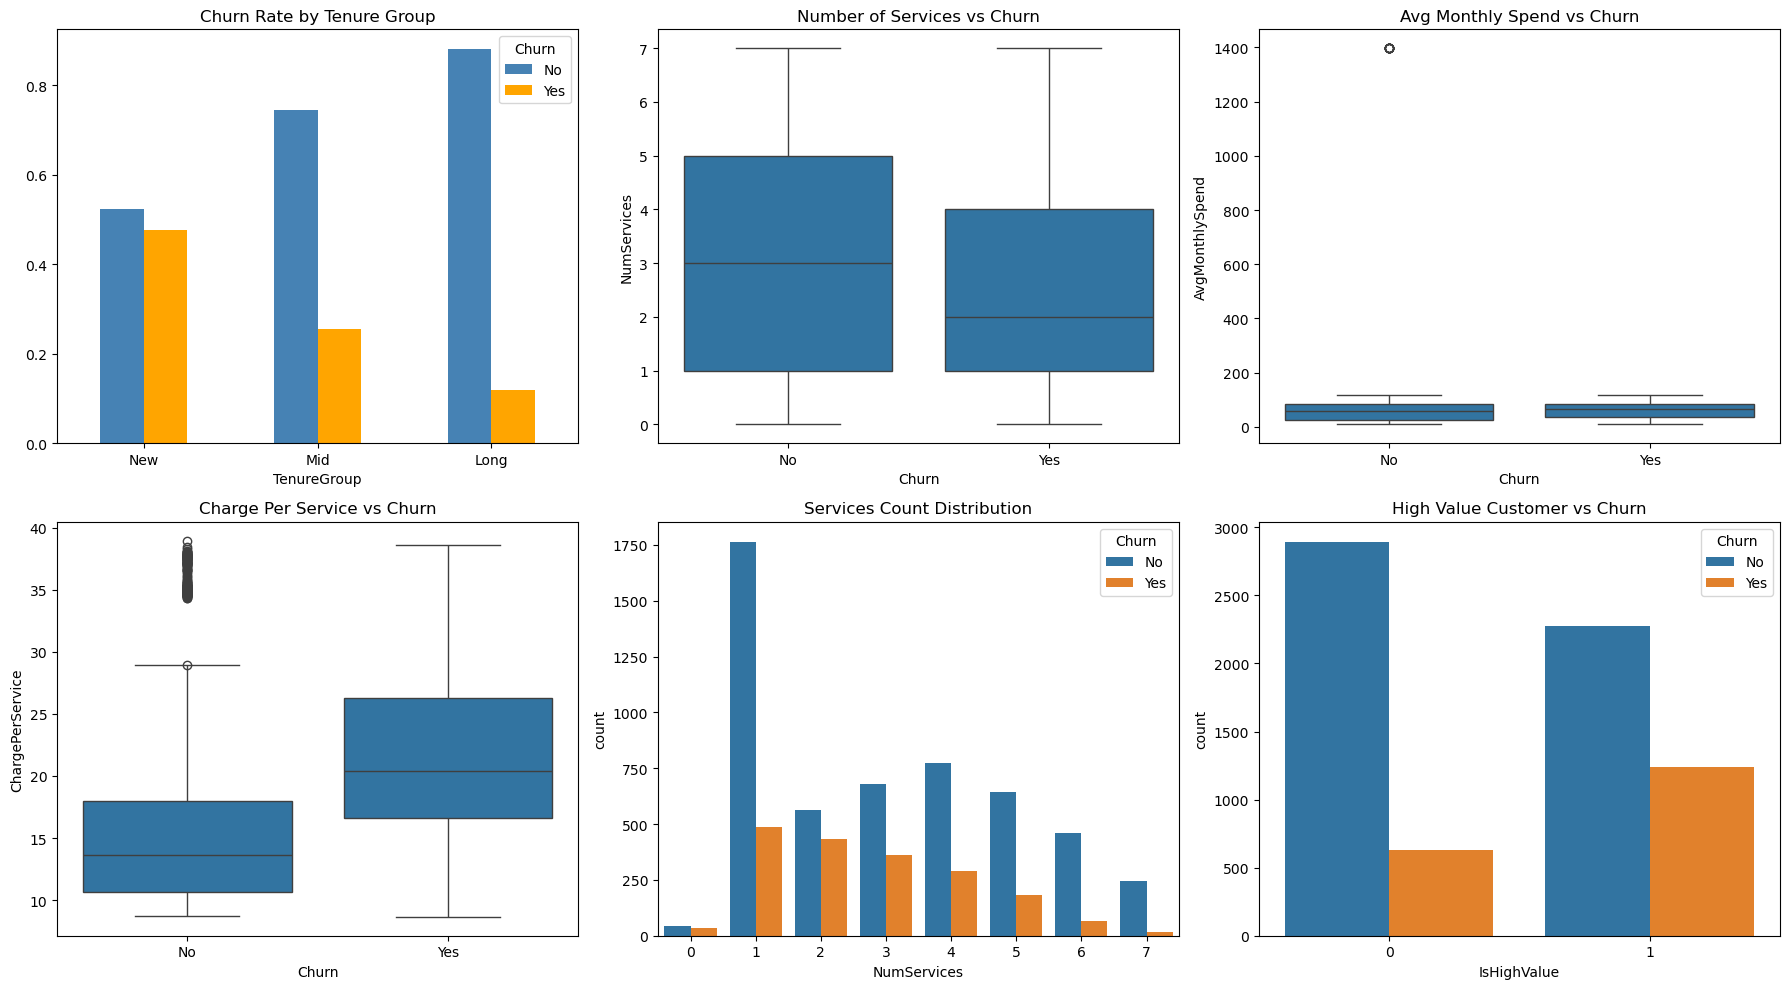

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. TenureGroup vs Churn
tenure_churn = df.groupby('TenureGroup')['Churn'].value_counts(
    normalize=True).unstack()
tenure_churn.plot(kind='bar', ax=axes[0,0], color=['steelblue', 'orange'])
axes[0,0].set_title('Churn Rate by Tenure Group')
axes[0,0].tick_params(axis='x', rotation=0)

# 2. NumServices vs Churn
sns.boxplot(x='Churn', y='NumServices', data=df, ax=axes[0,1])
axes[0,1].set_title('Number of Services vs Churn')

# 3. AvgMonthlySpend vs Churn
sns.boxplot(x='Churn', y='AvgMonthlySpend', data=df, ax=axes[0,2])
axes[0,2].set_title('Avg Monthly Spend vs Churn')

# 4. ChargePerService vs Churn
sns.boxplot(x='Churn', y='ChargePerService', data=df, ax=axes[1,0])
axes[1,0].set_title('Charge Per Service vs Churn')

# 5. NumServices distribution
sns.countplot(x='NumServices', hue='Churn', data=df, ax=axes[1,1])
axes[1,1].set_title('Services Count Distribution')

# 6. IsHighValue vs Churn
sns.countplot(x='IsHighValue', hue='Churn', data=df, ax=axes[1,2])
axes[1,2].set_title('High Value Customer vs Churn')

plt.tight_layout()
plt.show()

In [4]:
# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encode binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0})

# Encode TenureGroup
df['TenureGroup'] = df['TenureGroup'].map({'New': 0, 'Mid': 1, 'Long': 2})

# One hot encode remaining categoricals
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("Shape after all encoding:", df.shape)

Shape after all encoding: (7043, 37)


In [5]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=['Churn'])
y = df['Churn']

# New features list
new_features = ['AvgMonthlySpend', 'TenureGroup', 'NumServices',
                'IsHighValue', 'IsMonthToMonth', 'ChargePerService']

# Without new features
X_base = X.drop(columns=new_features)

# Split both
X_train_b, X_test_b, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=y)
X_train_f, X_test_f, _, _ = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Train & compare
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_base.fit(X_train_b, y_train)
auc_base = roc_auc_score(y_test, rf_base.predict_proba(X_test_b)[:,1])

rf_feat = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_feat.fit(X_train_f, y_train)
auc_feat = roc_auc_score(y_test, rf_feat.predict_proba(X_test_f)[:,1])

print(f"AUC without new features: {auc_base:.4f}")
print(f"AUC with new features:    {auc_feat:.4f}")
print(f"Improvement:              +{(auc_feat - auc_base):.4f}")

AUC without new features: 0.8225
AUC with new features:    0.8250
Improvement:              +0.0025


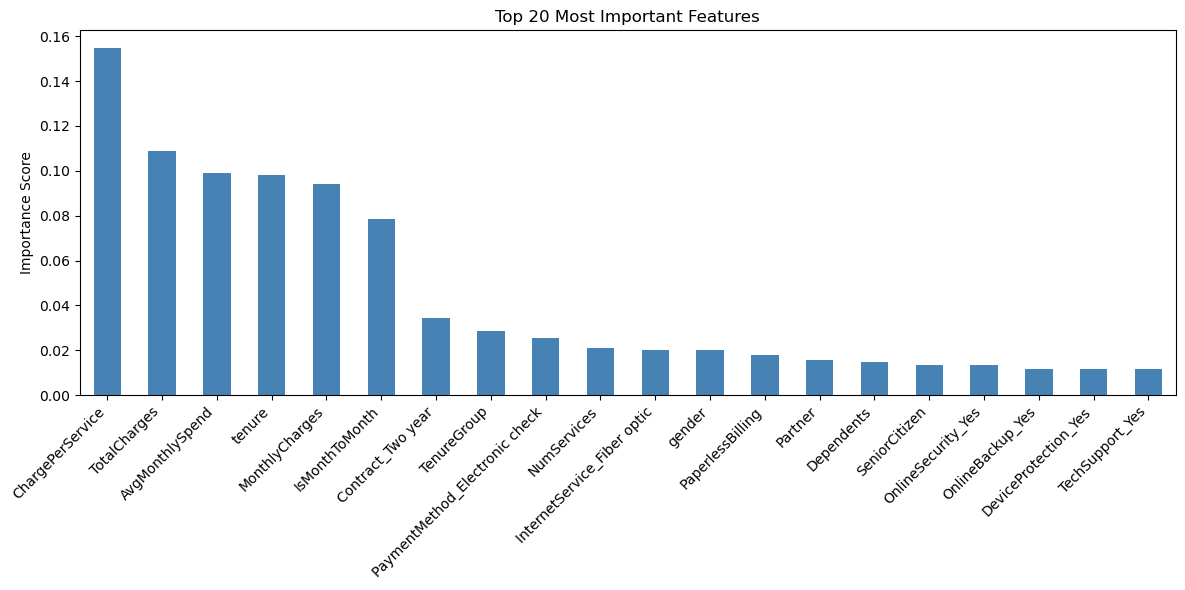


Top 10 features:
ChargePerService                  0.154890
TotalCharges                      0.109005
AvgMonthlySpend                   0.098837
tenure                            0.098103
MonthlyCharges                    0.094200
IsMonthToMonth                    0.078341
Contract_Two year                 0.034478
TenureGroup                       0.028372
PaymentMethod_Electronic check    0.025377
NumServices                       0.021180
dtype: float64


In [6]:
importances = pd.Series(rf_feat.feature_importances_, 
                         index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
importances[:20].plot(kind='bar', color='steelblue')
plt.title('Top 20 Most Important Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importances[:10])